In [1]:
import pandas as pd, numpy as np

%load_ext autoreload
%autoreload 2

!date

Wed Jul 31 18:11:07 PDT 2024


# HCES Data Extraction
We have HCES data to inform rice consumption (of PSD-distributed and non-PSD rice) by women and birthing people of 
reproductive age (WBPRA) and U5 children in India. We need to do further investigation as to what percentage of PSD-
distributed rice has been fortified with iron and folate.

HCES data and documentation is saved on Sharepoint here: https://uwnetid.sharepoint.com/:f:/r/sites/ihme_simulation_science_team/Shared%20Documents/Research/LSFF/07_Data/HCES_22_data_files?csf=1&web=1&e=wmxQSD

Item codes for 'Rice' include: 101, 102, and 061. See Section 5.1 of the above documentation for more context.
- Item code 101 signifies rice procured through PDS, using ration card.
- Item code 061 signifies rice procured through PDS, free of charge.
- Item code 102 signifies rice procured/consumed from other sources. (NOTE: Presumably this is unfortified rice.)

We also will need to approximate DHS wealth quintiles in the HCES data, by using similar variables as is used by the DHS to 
calculate wealth quintiles in India (see DHS wealth quintile documentation here: 
https://dhsprogram.com/programming/wealth%20index/India%20DHS%202015-16/India%202015-16%20sps.txt)

In this notebook, we extract the raw data from the HCES website and do some initial processing in order to create files 
that we can further tabulate based on our project needs in a later step. For now, we process these raw data into dataframes 
that have a row for each household/individual with the following columns:
- Whether or not rice was consumed (binary variable - this will be used to calculate coverage percentages later)
- Amount of PDS rice consumed (grams per day - currently in raw HCES, *I think* this is in kg per 2 weeks; this will be used to calculate fortified rice consumption amount) 
- Amount of non-PDS rice consumed (grams per day - currently in raw HCES, *I think* this is in kg per 2 weeks; this will be used to calculate unfortified rice consumption amount) 
- Wealth composite score/quintile 
- Sex/gender (will be used to calculate WBPRA)
- Age (will be used to tabulate age groups)

## Load data

In [2]:
data_dir = '/snfs1/DATA/Incoming Data/IND/HOUSEHOLD_CONSUMPTION_EXPENDITURE_SURVEY_HCES/2022_2023'

In [3]:
level_1_widths = [4, 4, 5, 1, 2, 3, 2, 2, 2, 2, 1, 4, 2, 1, 1, 2, 1, 2, 1, 1, 15]

level_1 = pd.read_fwf(
    f'{data_dir}/hces22_lvl_01.TXT',
    header=None,
    widths=level_1_widths,
    names=[
        "survey_name",
        "year",
        "fsu_serial_no",
        "sector",
        "state",
        "nss_region",
        "district",
        "stratum",
        "sub_stratum",
        "panel",
        "sub_sample",
        "fod_sub_region",
        "sample_su_no",
        "sample_sub_division_no",
        "second_stage_stratum_no",
        "sample_household_no",
        "questionnaire_no",
        "level",
        "survey_code",
        "reason_for_substitution_code",
        "multiplier"
    ],
)
level_1

,survey_name,year,fsu_serial_no,sector,state,nss_region,district,stratum,sub_stratum,panel,...,fod_sub_region,sample_su_no,sample_sub_division_no,second_stage_stratum_no,sample_household_no,questionnaire_no,level,survey_code,reason_for_substitution_code,multiplier
0,HCES,2022,65556,1,1,13,11,13,1,1,...,120,2.0,NaN,2,1,H,1,1,NaN,35560.0
1,HCES,2022,65556,1,1,13,11,13,1,1,...,120,2.0,NaN,3,1,H,1,1,NaN,30331.0
2,HCES,2022,65556,1,1,13,11,13,1,1,...,120,2.0,NaN,3,2,H,1,1,NaN,30331.0
3,HCES,2022,65556,1,1,13,11,13,1,1,...,120,2.0,NaN,3,3,H,1,1,NaN,30331.0
4,HCES,2022,65556,1,1,13,11,13,1,1,...,120,2.0,NaN,3,4,H,1,1,NaN,30331.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261741,HCES,2022,39510,2,28,283,13,22,2,10,...,2810,1.0,NaN,3,14,H,1,1,NaN,73515.0
261742,HCES,2022,39510,2,28,283,13,22,2,10,...,2810,1.0,NaN,3,15,H,1,1,NaN,73515.0
261743,HCES,2022,39510,2,28,283,13,22,2,10,...,2810,1.0,NaN,3,16,H,1,1,NaN,73515.0
261744,HCES,2022,39510,2,28,283,13,22,2,10,...,2810,1.0,NaN,3,17,H,1,1,NaN,73515.0


In [4]:
common_id_columns = level_1.columns[:16]
common_id_column_widths = level_1_widths[:16]

level_1["common_id"] = ""

for col, width in zip(common_id_columns, common_id_column_widths):
    fill_val = '0'
    side = 'left'
    if col in ('sample_su_no', 'sample_sub_division_no', 'panel'):
        # No clue.
        fill_val = ' '
        side = 'right'

    values = level_1[col].fillna(fill_val).astype(str).str.replace('.0', '').str.pad(width, fillchar=fill_val, side=side)
    assert (values.str.len() == width).all()
    level_1["common_id"] += values

level_1["common_id"]

0         HCES2022655561010131113011 101202  201
1         HCES2022655561010131113011 101202  301
2         HCES2022655561010131113011 101202  302
3         HCES2022655561010131113011 101202  303
4         HCES2022655561010131113011 101202  304
                           ...                  
261741    HCES20223951022828313220210228101  314
261742    HCES20223951022828313220210228101  315
261743    HCES20223951022828313220210228101  316
261744    HCES20223951022828313220210228101  317
261745    HCES20223951022828313220210228101  318
Name: common_id, Length: 261746, dtype: object

In [5]:
level_3 = pd.read_fwf(
    '/snfs1/DATA/Incoming Data/IND/HOUSEHOLD_CONSUMPTION_EXPENDITURE_SURVEY_HCES/2022_2023/hces22_lvl_03.TXT',
    header=None,
    widths=[38,1,2,2,1,3,5,1,1,1,1,1,1,1,1,1,9,1,1,1,1,1,2,1,2,3,1,2,1,1,1,1,2,15],
    names=[
        "common_id",
        "questionnaire_no",
        "level",
        "hh_size",
        "household_member_economic_activity_last_365_days",
        "nco_2015_code",
        "nic_2008_code",
        "max_income_source_last_365_days",
        "major_income_source_self_employment_sector",
        "major_income_regular_wage_sector",
        "major_income_casual_labour_sector",
        "household_type",
        "head_religion",
        "head_social_group",
        "land_ownership",
        "land_type_owned",
        "total_owned_land_area",
        "has_dwelling",
        "dwelling_unit_type",
        "building_material_wall",
        "building_material_roof",
        "building_material_floor",
        "cooking_energy_source",
        "lighting_energy_source",
        "drinking_water_source",
        "water_fetching_time_minutes",
        "latrine_access_type",
        "latrine_type",
        "ration_card_type",
        "rural_rent_rate_availability",
        "pmgky_benefit_status",
        "household_child_mortality_last_5_years",
        "child_mortality_count_last_5_years",
        "multiplier",
    ],
)
level_3

,common_id,questionnaire_no,level,hh_size,household_member_economic_activity_last_365_days,nco_2015_code,nic_2008_code,max_income_source_last_365_days,major_income_source_self_employment_sector,major_income_regular_wage_sector,...,drinking_water_source,water_fetching_time_minutes,latrine_access_type,latrine_type,ration_card_type,rural_rent_rate_availability,pmgky_benefit_status,household_child_mortality_last_5_years,child_mortality_count_last_5_years,multiplier
0,HCES2022655561010131113011 101202 201,H,3,5,1,332.0,68200.0,1.0,2.0,NaN,...,2,0.0,1,2.0,3,2.0,2,2,0,35560.0
1,HCES2022655561010131113011 101202 301,H,3,6,1,931.0,42909.0,3.0,NaN,NaN,...,2,0.0,1,2.0,2,2.0,2,2,0,30331.0
2,HCES2022655561010131113011 101202 302,H,3,8,1,833.0,49211.0,1.0,2.0,NaN,...,2,0.0,1,2.0,3,2.0,2,2,0,30331.0
3,HCES2022655561010131113011 101202 303,H,3,4,1,142.0,47713.0,1.0,2.0,NaN,...,2,0.0,1,2.0,0,2.0,2,2,0,30331.0
4,HCES2022655561010131113011 101202 304,H,3,4,1,833.0,49211.0,1.0,2.0,NaN,...,2,0.0,1,2.0,3,2.0,2,2,0,30331.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261741,HCES20223951022828313220210228101 314,H,3,2,1,832.0,49219.0,1.0,NaN,NaN,...,11,10.0,1,1.0,4,NaN,1,2,0,73515.0
261742,HCES20223951022828313220210228101 315,H,3,4,1,216.0,85500.0,2.0,NaN,NaN,...,2,0.0,1,1.0,0,NaN,1,2,0,73515.0
261743,HCES20223951022828313220210228101 316,H,3,3,1,411.0,84119.0,2.0,NaN,NaN,...,2,0.0,1,1.0,4,NaN,1,2,0,73515.0
261744,HCES20223951022828313220210228101 317,H,3,5,1,112.0,47711.0,1.0,NaN,NaN,...,2,0.0,1,1.0,4,NaN,1,2,0,73515.0


In [6]:
assert level_3.common_id.is_unique

In [7]:
level_3.cooking_energy_source

0         2
1         2
2         2
3         2
4         2
         ..
261741    2
261742    2
261743    2
261744    2
261745    2
Name: cooking_energy_source, Length: 261746, dtype: int64

In [8]:
binary_columns = ["land_ownership", "has_dwelling"]

for col in binary_columns:
    level_3[col] = level_3[col].map({
        1: 1.0,
        2: 0.0,
    }).astype(float)

In [9]:
level_3.loc[level_3.land_ownership == 0, "total_owned_land_area"] = 0

In [10]:
level_3["dwelling_unit_type"] = level_3.dwelling_unit_type.map({
    1: 'owned',
    2: 'hired',
    3: 'others',
})
level_3["house_ownership"] = (level_3.has_dwelling == 1) & (level_3.dwelling_unit_type == 'owned')

In [11]:
materials = {
    1: 'grass',
    2: 'mud',
    3: 'canvas',
    4: 'katcha',
    5: 'tiles',
    6: 'brick',
    7: 'metal',
    8: 'cement',
    9: 'pucca',
}

for col in ["building_material_wall", "building_material_roof", "building_material_floor"]:
    level_3[col] = level_3[col].map(materials)
    level_3.loc[level_3.has_dwelling == 0, col] = 'none'

In [12]:
level_3["cooking_energy_source"] = level_3.cooking_energy_source.map({
    1: 'firewood',
    2: 'liquid petroleum gas',
    3: 'other natural gas',
    4: 'dung',
    5: 'kerosene',
    6: 'coal',
    7: 'gobar',
    8: 'other biogas',
    10: 'charcoal',
    11: 'electricity',
    12: 'no cooking',
    9: 'other',
})

In [13]:
level_3["lighting_energy_source"] = level_3.lighting_energy_source.map({
    1: 'electricity',
    2: 'kerosene',
    3: 'other oil',
    4: 'gas',
    5: 'candle',
    6: 'no lighting',
    9: 'other',
})

In [14]:
level_3["drinking_water_source"] = level_3.drinking_water_source.map({
    1: 'bottled',
    2: 'piped into dwelling',
    3: 'piped to yard',
    4: 'piped from neighbor',
    5: 'public tap',
    6: 'tube well',
    7: 'hand pump',
    8: 'well: protected',
    9: 'well: unprotected',
    10: 'tanker-truck: public',
    11: 'tanker-truck: private',
    12: 'spring: protected',
    13: 'spring: unprotected',
    14: 'rainwater collection',
    15: 'tank or pond',
    16: 'other surface water',
    19: 'other',
})

In [15]:
level_3["latrine_access_type"] = level_3.latrine_access_type.map({
    1: 'exclusive',
    2: 'common',
    3: 'public, free',
    4: 'public, paid',
    5: 'no latrine',
    9: 'other',
})

In [16]:
level_3["latrine_type"] = level_3.latrine_type.map({
    1: 'flush to piped',
    2: 'flush to septic',
    3: 'flush to twin leach pit',
    4: 'flush to single leach pit',
    5: 'other flush',
    6: 'improved pit',
    7: 'pit with slab',
    8: 'pit without slab',
    10: 'composting',
    11: 'open',
    19: 'other',
})

In [17]:
level_3["latrine_access_and_type"] = np.where(
    level_3.latrine_access_type == 'no latrine',
    'no latrine',
    np.where(
        level_3.latrine_access_type.notnull() & level_3.latrine_type.notnull(),
        (level_3["latrine_access_type"] == 'exclusive').map({True: "", False: "shared "}) + level_3.latrine_type,
        np.nan
    ) 
)

<Axes: >

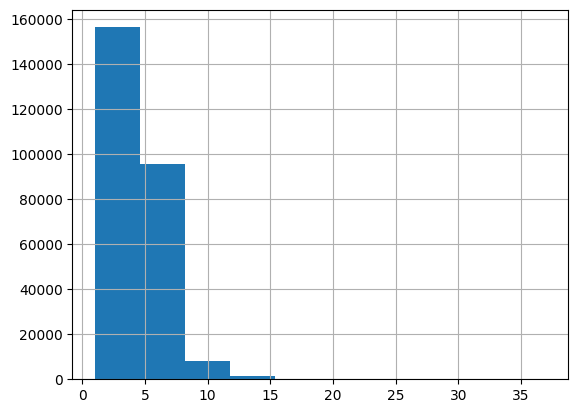

In [18]:
# The fact that there are a couple very large households (e.g. 20+ members) is a little 
# surprising - maybe we can investigate to confirm these are some kind of GQ. 
level_3.hh_size.hist()

In [19]:
level_7 = pd.read_fwf(
    f'{data_dir}/hces22_lvl_07.TXT', 
    header = None, 
    widths = [38,1,2,1,1,2,1,1,3,3,1,3,1,3,1,3,1,3,1,2,1,2,1,1,2,8,1,1,1,1,1,1,15], 
    names=['common_id','questionnaire_no','level','kerosene','lpg_subsidy','num_lpg_subsidy','days','attend_education',
        'unk','num_attend_priv_ed','free_items','free_textbooks','free_stationary','num_free_stationary',
        'free_school_bag','num_free_school_bag','other_free_items','num_other_free_items','fee_waiver',
        'num_free_waiver','benefit_pmjay','num_benefit_pmjay','hospitalization','pmjay_hosp_benefit',
        'pmjay_hosp_benefit_num','pmjay_hosp_benefit_amt','fuel_light','toilet','education','medicine',
        'services','internet','multiplier'],
)
level_7

,common_id,questionnaire_no,level,kerosene,lpg_subsidy,num_lpg_subsidy,days,attend_education,unk,num_attend_priv_ed,...,pmjay_hosp_benefit,pmjay_hosp_benefit_num,pmjay_hosp_benefit_amt,fuel_light,toilet,education,medicine,services,internet,multiplier
0,HCES2022655561010131113011 101202 201,C,7,2,1,1.0,2,1,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,35560.0
1,HCES2022655561010131113011 101202 301,C,7,2,1,1.0,2,1,2.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,30331.0
2,HCES2022655561010131113011 101202 302,C,7,2,1,2.0,2,1,0.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,30331.0
3,HCES2022655561010131113011 101202 303,C,7,2,2,NaN,2,1,NaN,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,30331.0
4,HCES2022655561010131113011 101202 304,C,7,2,1,1.0,2,2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,30331.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261741,HCES20223951022828313220210228101 314,C,7,2,2,NaN,2,2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,73515.0
261742,HCES20223951022828313220210228101 315,C,7,2,2,NaN,2,2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,73515.0
261743,HCES20223951022828313220210228101 316,C,7,2,2,NaN,2,2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1,73515.0
261744,HCES20223951022828313220210228101 317,C,7,2,2,NaN,2,2,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,73515.0


In [20]:
assert level_7.common_id.is_unique

In [21]:
binary_columns = ["internet"]

for col in binary_columns:
    level_7[col] = level_7[col].map({
        1: 1.0,
        2: 0.0,
    }).astype(float)

In [22]:
level_11 = pd.read_fwf(
    '/snfs1/DATA/Incoming Data/IND/HOUSEHOLD_CONSUMPTION_EXPENDITURE_SURVEY_HCES/2022_2023/hces22_lvl_11.TXT', 
    header = None, 
    widths = [38,1,2,1,1,1,1,1,1,1,1,1,1,1,1,3,1,3,1,3,1,3,1,3,1,3,1,3,1,3,1,1,1,1,1,1,1,1,1,1,1,1,1,15], 
    names=['common_id','questionnaire_no','level','clothing','footwear','furniture','recently_bought_mobile_handset',
        'personal_goods','recreation_goods','cooking','crockery','sports_goods','med_equip','bedding','free_laptop',
        'num_free_laptop','free_tablet','num_free_tablet','free_mobile','num_free_mobile','free_bicycle',
        'num_free_bicycle','free_motorcycle','num_free_motorcycle','free_clothing','num_free_clothing',
        'free_footwear','num_free_footwear','other_free','num_other_free','tv','radio','laptop',
        'mobile_handset','bicycle','motorcycle','motor_car','trucks','animal_cart','refrigerator',
        'washing_machine','air_conditioner','multichannel_tv_type','multiplier']
)
level_11

,common_id,questionnaire_no,level,clothing,footwear,furniture,recently_bought_mobile_handset,personal_goods,recreation_goods,cooking,...,bicycle,motorcycle,motor_car,trucks,animal_cart,refrigerator,washing_machine,air_conditioner,multichannel_tv_type,multiplier
0,HCES2022655561010131113011 101202 201,D,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,1.0,NaN,NaN,1.0,1.0,NaN,3.0,35560.0
1,HCES2022655561010131113011 101202 301,D,11,NaN,NaN,NaN,NaN,NaN,1.0,NaN,...,1.0,1.0,NaN,NaN,NaN,1.0,1.0,NaN,2.0,30331.0
2,HCES2022655561010131113011 101202 302,D,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,1.0,NaN,NaN,NaN,1.0,1.0,NaN,3.0,30331.0
3,HCES2022655561010131113011 101202 303,D,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,NaN,1.0,NaN,NaN,1.0,1.0,NaN,2.0,30331.0
4,HCES2022655561010131113011 101202 304,D,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,1.0,NaN,NaN,NaN,NaN,1.0,1.0,NaN,2.0,30331.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261741,HCES20223951022828313220210228101 314,D,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,1.0,NaN,NaN,1.0,1.0,NaN,2.0,73515.0
261742,HCES20223951022828313220210228101 315,D,11,NaN,NaN,1.0,NaN,NaN,NaN,1.0,...,NaN,1.0,1.0,NaN,NaN,1.0,1.0,1.0,1.0,73515.0
261743,HCES20223951022828313220210228101 316,D,11,1.0,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,NaN,NaN,NaN,1.0,1.0,NaN,1.0,73515.0
261744,HCES20223951022828313220210228101 317,D,11,1.0,1.0,NaN,NaN,NaN,NaN,NaN,...,NaN,1.0,NaN,NaN,NaN,1.0,1.0,1.0,2.0,73515.0


In [23]:
assert level_11.common_id.is_unique

In [24]:
level_11.tv.value_counts(dropna=False)

tv
1.0    180715
NaN     81031
Name: count, dtype: int64

In [25]:
possession_columns = [
    'tv',
    'radio',
    'laptop',
    'mobile_handset',
    'bicycle',
    'motorcycle',
    'motor_car',
    'trucks',
    'animal_cart',
    'refrigerator',
    'washing_machine',
    'air_conditioner',
]

In [26]:
level_11[possession_columns].isnull().mean()

tv                 0.309579
radio              0.968076
laptop             0.918024
mobile_handset     0.032975
bicycle            0.594745
motorcycle         0.454517
motor_car          0.916770
trucks             0.998418
animal_cart        0.992428
refrigerator       0.565185
washing_machine    0.779699
air_conditioner    0.753521
dtype: float64

In [27]:
(level_11[possession_columns] == 0).mean()

tv                 0.0
radio              0.0
laptop             0.0
mobile_handset     0.0
bicycle            0.0
motorcycle         0.0
motor_car          0.0
trucks             0.0
animal_cart        0.0
refrigerator       0.0
washing_machine    0.0
air_conditioner    0.0
dtype: float64

In [28]:
for col in possession_columns:
    level_11[col] = level_11[col].fillna(0.0)

In [29]:
household_levels = [level_1, level_3, level_7, level_11]

In [30]:
level_specific_columns = ["level", "questionnaire_no"]

def drop_level_specific(df):
    return df[[c for c in df.columns if c not in level_specific_columns]]

households = drop_level_specific(household_levels[0])

for additional_level in household_levels[1:]:
    common_columns = (set(households.columns) & set(additional_level.columns)) - {'common_id'}
    households = households.merge(drop_level_specific(additional_level), on="common_id", validate="1:1", how="outer")
    for column in common_columns:
        assert (households[f'{column}_x'] == households[f'{column}_y']).all()
        households[column] = households[f'{column}_x']
        households = households.drop(columns=[f'{column}_x', f'{column}_y'])

households

,survey_name,year,fsu_serial_no,sector,state,nss_region,district,stratum,sub_stratum,panel,...,bicycle,motorcycle,motor_car,trucks,animal_cart,refrigerator,washing_machine,air_conditioner,multichannel_tv_type,multiplier
0,HCES,2022,31000,2,28,283,12,12,2,5,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,96498.0
1,HCES,2022,31000,2,28,283,12,12,2,5,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,96498.0
2,HCES,2022,31000,2,28,283,12,12,2,5,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,96498.0
3,HCES,2022,31000,2,28,283,12,12,2,5,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,3.0,96498.0
4,HCES,2022,31000,2,28,283,12,12,2,5,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,96498.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261741,HCES,2022,69999,1,21,213,1,23,9,3,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,125023.0
261742,HCES,2022,69999,1,21,213,1,23,9,3,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,125023.0
261743,HCES,2022,69999,1,21,213,1,23,9,3,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,125023.0
261744,HCES,2022,69999,1,21,213,1,23,9,3,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,3.0,125023.0


In [31]:
# Bizarrely, I can't find documentation of these codes -- but we know the rent rate is only asked for rural
households.assign(rent_rate=households.rural_rent_rate_availability.notnull()).groupby('sector').rent_rate.mean()

sector
1    1.0
2    0.0
Name: rent_rate, dtype: float64

In [32]:
households["sector"] = households.sector.map({1: 'rural', 2: 'urban'})
households.sector.value_counts(dropna=False)

sector
rural    155014
urban    106732
Name: count, dtype: int64

In [33]:
households.isnull().mean().sort_values()

survey_name            0.000000
year                   0.000000
fsu_serial_no          0.000000
sector                 0.000000
state                  0.000000
                         ...   
num_free_laptop        0.999282
free_mobile            0.999366
num_free_mobile        0.999366
num_free_motorcycle    0.999893
free_motorcycle        0.999893
Length: 121, dtype: float64

## Calculate wealth quintiles

In order to add wealth stratifications into our HCES data, we will emulate DHS methods for calculating wealth quintiles.
They don't ask something like "how wealthy are you?"
Instead, they ask "do you have a refrigerator?" and then a bunch of other questions like that,
and analyze them into a composite wealth index.
The way they do so is actually pretty weird and interesting, but I won't get into that here.
It is described at https://dhsprogram.com/topics/wealth-index/Wealth-Index-Construction.cfm.

In a first pass, we attempted to use the DHS weights directly.
See [this past version of the notebook](https://github.com/ihmeuw/vivarium_gates_lsff_by_wealth_quintile/blob/12d63b4c5a3b7cb204c4f6eb3de7d6ffe87ce9c3/0100_data_prep/01_extract_hces.ipynb)
for how we started to do this.

However, this was tricky,
because none of the questions asked in HCES are exactly the same, with the same answer options,
as in DHS.
We could sort of use proxies and fudge things, but it was pretty rough.
Here, I have instead used the same *methods* used in the DHS to make an entirely new
model of the latent wealth variable.
I followed the steps described here: https://dhsprogram.com/programming/wealth%20index/Steps_to_constructing_the_new_DHS_Wealth_Index.pdf

However, even this is pretty underwhelming. Probably a better strategy to try in the future would be to make a more complex and
precise crosswalk between DHS and HCES questions/responses, then train a model in DHS to predict the DHS wealth quintile based
only on information available in HCES, and finally predict HCES.

DHS wealth index variables include: 
- Source of drinking water
- Type of toilet facility
- Electricity
- Mattress
- Pressure cooker
- Chair
- Cot or bed
- Table
- Electric fan
- Radio or transistor
- Black and white television
- Colour television
- Sewing machine
- Mobile telephone
- Telephone (non-mobile)
- Internet
- Computer
- Refrigerator
- Air conditioner/cooler
- Washing machine
- Watch or clock
- Bicycle
- Motorcycle or Scooter
- Animal-drawn cart
- Car
- Water pump
- Thresher
- Tractor
- Type of cooking fuel
- Main material of floor
- Main roof material
- Main wall material
- Hectares for agricultural land
- Out of this land, how much is irrigated?
- Cows / bulls / buffaloes
- Camels
- Horses / donkeys / mules
- Goats
- Sheep
- Chickens / ducks
- Bank account
- Members per sleeping room
- Compute urban and rural variables coded (1/0) for filters later
- Toilet facility by shared/not shared
- Land area by units - if there are separate units - need to convert them to one unit

HCES variables:
- Type of land owned
- What is the total area of all owned (owned and possessed or leased out) land (within the country) by the household as on the date of survey (area in acre)?(upto two places of decimal) 
- Basic building Material used for major portion of the wall of the dwelling Unit
- Basic building Material used for construction of the major portion of the outer exposed part of the roof of the dwelling unit
- Basic Building Material used for construction of the major portion of the floor of the dwelling Unit
- Source of Drinking Water (Last 365 days)
- Type of latrine in which the household has access
- Primary source of energy of the household for cooking
- Household has internet facility as on the date of the survey
- Whether household possessed one or more item as on the date of the survey- Television 
- Whether household possessed one or more item as on the date of the survey- Radio
- Whether household possessed one or more item as on the date of the survey - Laptop/PC
- Whether household possessed one or more item as on the date of the survey- Mobile handset
- Whether household possessed one or more item as on the date of the survey- Bicycle
- Whether household possessed one or more item as on the date of the survey- Motorcycle, scooter 
- Whether household possessed one or more item as on the date of the survey- Motor car/jeep/van
- Whether household possessed one or more item as on the date of the survey- Trucks
- Whether household possessed one or more item as on the date of the survey - Animal cart
- Whether household possessed one or more item as on the date of the survey- Refrigerator
- Whether household possessed one or more item as on the date of the survey- Washing machine
- Whether household possessed one or more item as on the date of the survey- Air conditioner/air cooler 
- Type of multichannel television facility is used by the household as on the date of the survey

Crosswalk spreadsheet saved here: https://uwnetid.sharepoint.com/sites/ihme_simulation_science_team/_layouts/15/doc.aspx?sourcedoc={eddcbf51-3462-47d7-b847-79edea5046c6}&action=edit

In [34]:
wealth_relevant_info = households[[
    'sector',
    'hh_size',
    'multiplier',
    # Section/level 4
    'land_ownership',
    # 'total_owned_land_area',
    'has_dwelling',
    'house_ownership',
    'building_material_wall',
    'building_material_roof',
    'building_material_floor',
    'cooking_energy_source',
    'lighting_energy_source',
    'drinking_water_source',
    # Cross-tab latrine type with whether shared
    'latrine_access_and_type',
    # Section 4.2
    'internet',
    # Section 4.3
    *possession_columns,
]].copy()
wealth_relevant_info

,sector,hh_size,multiplier,land_ownership,has_dwelling,house_ownership,building_material_wall,building_material_roof,building_material_floor,cooking_energy_source,...,laptop,mobile_handset,bicycle,motorcycle,motor_car,trucks,animal_cart,refrigerator,washing_machine,air_conditioner
0,urban,1,96498.0,1.0,1.0,False,brick,metal,brick,liquid petroleum gas,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,urban,5,96498.0,1.0,1.0,False,brick,cement,brick,liquid petroleum gas,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
2,urban,5,96498.0,1.0,1.0,False,brick,cement,brick,liquid petroleum gas,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
3,urban,2,96498.0,1.0,1.0,True,brick,metal,brick,liquid petroleum gas,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,urban,1,96498.0,1.0,1.0,True,brick,cement,brick,liquid petroleum gas,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261741,rural,8,125023.0,1.0,1.0,True,pucca,tiles,mud,firewood,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
261742,rural,2,125023.0,1.0,1.0,True,pucca,tiles,mud,firewood,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
261743,rural,4,125023.0,1.0,1.0,True,brick,cement,cement,firewood,...,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
261744,rural,5,125023.0,1.0,1.0,True,brick,cement,cement,firewood,...,0.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0


In [35]:
wealth_relevant_info.isnull().mean()

sector                     0.0
hh_size                    0.0
multiplier                 0.0
land_ownership             0.0
has_dwelling               0.0
house_ownership            0.0
building_material_wall     0.0
building_material_roof     0.0
building_material_floor    0.0
cooking_energy_source      0.0
lighting_energy_source     0.0
drinking_water_source      0.0
latrine_access_and_type    0.0
internet                   0.0
tv                         0.0
radio                      0.0
laptop                     0.0
mobile_handset             0.0
bicycle                    0.0
motorcycle                 0.0
motor_car                  0.0
trucks                     0.0
animal_cart                0.0
refrigerator               0.0
washing_machine            0.0
air_conditioner            0.0
dtype: float64

In [36]:
wealth_relevant_info.nunique()

sector                         2
hh_size                       31
multiplier                 23607
land_ownership                 2
has_dwelling                   2
house_ownership                2
building_material_wall        10
building_material_roof        10
building_material_floor       10
cooking_energy_source         12
lighting_energy_source         7
drinking_water_source         17
latrine_access_and_type       22
internet                       2
tv                             2
radio                          2
laptop                         2
mobile_handset                 2
bicycle                        2
motorcycle                     2
motor_car                      2
trucks                         2
animal_cart                    2
refrigerator                   2
washing_machine                2
air_conditioner                2
dtype: int64

In [37]:
columns_to_convert = [
    'building_material_wall',
    'building_material_roof',
    'building_material_floor',
    'cooking_energy_source',
    'lighting_energy_source',
    'drinking_water_source',
    'latrine_access_and_type',
]

for column in columns_to_convert:
    # Get dummy variables for the current column
    dummies = pd.get_dummies(wealth_relevant_info[column], prefix=column)
    
    # Drop the original column from hces_df
    wealth_relevant_info = wealth_relevant_info.drop(column, axis=1)
    
    # Join the dummy variables to the original DataFrame
    wealth_relevant_info = pd.concat([wealth_relevant_info, dummies], axis=1)

In [38]:
wealth_predictors = [c for c in wealth_relevant_info.columns if c not in ('sector', 'hh_size', 'multiplier')]

In [39]:
from sklearn.decomposition import PCA

pca = PCA(n_components=1)
pca.fit(wealth_relevant_info.drop(columns=["sector", 'multiplier', 'hh_size']).dropna(how='any'))

PCA(n_components=1)

In [40]:
pd.DataFrame({
    "column": wealth_relevant_info.drop(columns=["sector", 'multiplier', 'hh_size']).columns,
    "scores": pd.Series(pca.components_[0]).astype(float),
}).sort_values('scores')

,column,scores
50,cooking_energy_source_firewood,-0.332121
42,building_material_floor_mud,-0.211374
66,drinking_water_source_hand pump,-0.201371
31,building_material_roof_metal,-0.157884
8,bicycle,-0.135724
...,...,...
9,motorcycle,0.246566
4,tv,0.264903
28,building_material_roof_cement,0.269550
53,cooking_energy_source_liquid petroleum gas,0.341292


In [41]:
wealth_relevant_info["common_score"] = pca.transform(wealth_relevant_info.drop(columns=["sector", 'multiplier', 'hh_size']))

In [42]:
wealth_relevant_info.sector.value_counts()

sector
rural    155014
urban    106732
Name: count, dtype: int64

In [43]:
scores = {}

for sector in ["urban", "rural"]:
    print(sector)
    sector_rows = wealth_relevant_info.sector == sector

    pca = PCA(n_components=1)
    pca.fit(wealth_relevant_info[sector_rows][wealth_predictors].dropna(how='any'))

    display(pd.DataFrame({
        "column": wealth_predictors,
        "scores": pd.Series(pca.components_[0]).astype(float),
    }).sort_values('scores'))

    wealth_relevant_info.loc[sector_rows, f"{sector}_score"] = pca.transform(wealth_relevant_info[sector_rows][wealth_predictors])

urban


,column,scores
38,building_material_floor_cement,-0.202654
31,building_material_roof_metal,-0.184361
95,latrine_access_and_type_shared flush to septic,-0.096225
50,cooking_energy_source_firewood,-0.088282
71,drinking_water_source_piped to yard,-0.077376
...,...,...
45,building_material_floor_tiles,0.284999
15,air_conditioner,0.303321
9,motorcycle,0.309448
14,washing_machine,0.367206


rural


,column,scores
50,cooking_energy_source_firewood,-0.359039
42,building_material_floor_mud,-0.273167
66,drinking_water_source_hand pump,-0.222534
8,bicycle,-0.143104
88,latrine_access_and_type_no latrine,-0.138695
...,...,...
28,building_material_roof_cement,0.243380
9,motorcycle,0.271464
13,refrigerator,0.289802
4,tv,0.301591


In [44]:
import statsmodels.api as sm

for sector in ["urban", "rural"]:
    print(sector)
    sector_rows = wealth_relevant_info.sector == sector

    mod = sm.OLS(wealth_relevant_info[sector_rows][['common_score']], sm.add_constant(wealth_relevant_info[sector_rows][[f"{sector}_score"]]))
    fii = mod.fit()
    print(fii.summary2())

    wealth_relevant_info.loc[sector_rows, "combined_score"] = fii.predict(sm.add_constant(wealth_relevant_info[sector_rows][[f"{sector}_score"]]))

urban
                  Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.853     
Dependent Variable: common_score     AIC:                43078.2973
Date:               2024-07-31 18:12 BIC:                43097.4535
No. Observations:   106732           Log-Likelihood:     -21537.   
Df Model:           1                F-statistic:        6.193e+05 
Df Residuals:       106730           Prob (F-statistic): 0.00      
R-squared:          0.853            Scale:              0.087660  
---------------------------------------------------------------------
              Coef.    Std.Err.      t       P>|t|    [0.025   0.975]
---------------------------------------------------------------------
const         0.6506     0.0009   717.8467   0.0000   0.6488   0.6523
urban_score   0.7990     0.0010   786.9735   0.0000   0.7970   0.8010
-------------------------------------------------------------------
Omnibus:            17128.237      Durbin-Watson: 

                   Results: Ordinary least squares
Model:              OLS              Adj. R-squared:     0.982       
Dependent Variable: common_score     AIC:                -203702.2206
Date:               2024-07-31 18:12 BIC:                -203682.3181
No. Observations:   155014           Log-Likelihood:     1.0185e+05  
Df Model:           1                F-statistic:        8.684e+06   
Df Residuals:       155012           Prob (F-statistic): 0.00        
R-squared:          0.982            Scale:              0.015733    
----------------------------------------------------------------------
                Coef.   Std.Err.      t       P>|t|    [0.025   0.975]
----------------------------------------------------------------------
const          -0.4479    0.0003  -1406.0033  0.0000  -0.4486  -0.4473
rural_score     0.9569    0.0003   2946.8799  0.0000   0.9563   0.9576
---------------------------------------------------------------------
Omnibus:              6357.996    

<Axes: >

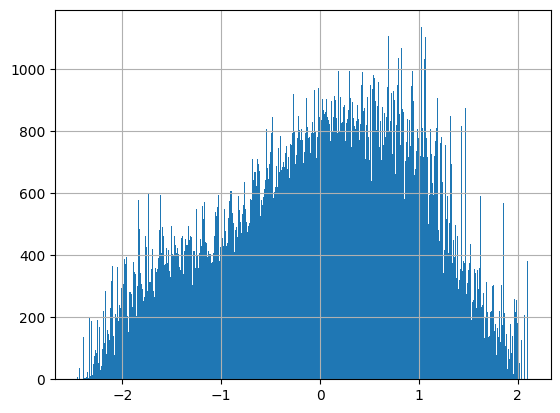

In [45]:
wealth_relevant_info.combined_score.hist(bins=500)

In [46]:
wealth_relevant_info['weighted_household_size'] = wealth_relevant_info.hh_size * wealth_relevant_info.multiplier

from statsmodels.stats.weightstats import DescrStatsW
wq = DescrStatsW(data=wealth_relevant_info.combined_score, weights=wealth_relevant_info.weighted_household_size)
quintile_cutoffs = wq.quantile(probs=np.linspace(0, 1, 6))
quintile_cutoffs

p
0.0   -2.453442
0.2   -1.142439
0.4   -0.339699
0.6    0.296405
0.8    0.887782
1.0    2.106418
dtype: float64

In [47]:
wealth_relevant_info["wealth_quintile"] = pd.cut(wealth_relevant_info.combined_score, quintile_cutoffs, labels=["lowest", "second", "middle", "fourth", "highest"], include_lowest=True)
wealth_relevant_info["wealth_quintile"]

0         second
1         fourth
2         fourth
3         middle
4         fourth
           ...  
261741    lowest
261742    lowest
261743    second
261744    second
261745    lowest
Name: wealth_quintile, Length: 261746, dtype: category
Categories (5, object): ['lowest' < 'second' < 'middle' < 'fourth' < 'highest']

In [48]:
assert wealth_relevant_info.wealth_quintile.notnull().all()

In [49]:
wealth_relevant_info.groupby("wealth_quintile", observed=True).multiplier.sum() / wealth_relevant_info.multiplier.sum()

wealth_quintile
lowest     0.194822
second     0.197195
middle     0.210537
fourth     0.198687
highest    0.198759
Name: multiplier, dtype: float64

In [50]:
for column in wealth_predictors:
    print(column)
    print(wealth_relevant_info.groupby(["wealth_quintile", column], observed=True).multiplier.sum() / wealth_relevant_info.groupby("wealth_quintile").multiplier.sum())

land_ownership
wealth_quintile  land_ownership
lowest           0.0               0.017001
                 1.0               0.982999
second           0.0               0.064876
                 1.0               0.935124
middle           0.0               0.121395
                 1.0               0.878605
fourth           0.0               0.084162
                 1.0               0.915838
highest          0.0               0.078404
                 1.0               0.921596
Name: multiplier, dtype: float64
has_dwelling
wealth_quintile  has_dwelling
lowest           0.0             0.000067
                 1.0             0.999933
second           0.0             0.000251
                 1.0             0.999749
middle           1.0             1.000000
fourth           1.0             1.000000
highest          1.0             1.000000
Name: multiplier, dtype: float64
house_ownership
wealth_quintile  house_ownership
lowest           False              0.023653
                

/tmp/ipykernel_2495828/3807259362.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(wealth_relevant_info.groupby(["wealth_quintile", column], observed=True).multiplier.sum() / wealth_relevant_info.groupby("wealth_quintile").multiplier.sum())


wealth_quintile  mobile_handset
lowest           0.0               0.094412
                 1.0               0.905588
second           0.0               0.062103
                 1.0               0.937897
middle           0.0               0.027540
                 1.0               0.972460
fourth           0.0               0.004637
                 1.0               0.995363
highest          0.0               0.002159
                 1.0               0.997841
Name: multiplier, dtype: float64
bicycle
wealth_quintile  bicycle
lowest           0.0        0.275878
                 1.0        0.724122
second           0.0        0.462003
                 1.0        0.537997
middle           0.0        0.607478
                 1.0        0.392522
fourth           0.0        0.680164
                 1.0        0.319836
highest          0.0        0.716008
                 1.0        0.283992
Name: multiplier, dtype: float64
motorcycle
wealth_quintile  motorcycle
lowest           0.0

wealth_quintile  air_conditioner
lowest           0.0                0.967706
                 1.0                0.032294
second           0.0                0.880995
                 1.0                0.119005
middle           0.0                0.821039
                 1.0                0.178961
fourth           0.0                0.727671
                 1.0                0.272329
highest          0.0                0.399835
                 1.0                0.600165
Name: multiplier, dtype: float64
building_material_wall_brick
wealth_quintile  building_material_wall_brick
lowest           False                           0.593956
                 True                            0.406044
second           False                           0.300867
                 True                            0.699133
middle           False                           0.230983
                 True                            0.769017
fourth           False                           0.208929
   

wealth_quintile  building_material_wall_pucca
lowest           False                           0.967318
                 True                            0.032682
second           False                           0.981767
                 True                            0.018233
middle           False                           0.990395
                 True                            0.009605
fourth           False                           0.995349
                 True                            0.004651
highest          False                           0.997467
                 True                            0.002533
Name: multiplier, dtype: float64
building_material_wall_tiles
wealth_quintile  building_material_wall_tiles
lowest           False                           0.997513
                 True                            0.002487
second           False                           0.997916
                 True                            0.002084
middle           False            

...

wealth_quintile  lighting_energy_source_gas
lowest           False                         0.999970
                 True                          0.000030
second           False                         0.999947
                 True                          0.000053
middle           False                         0.999965
                 True                          0.000035
fourth           False                         0.999947
                 True                          0.000053
highest          False                         0.999968
                 True                          0.000032
Name: multiplier, dtype: float64
lighting_energy_source_kerosene
wealth_quintile  lighting_energy_source_kerosene
lowest           False                              0.990498
                 True                               0.009502
second           False                              0.997921
                 True                               0.002079
middle           False                

wealth_quintile  drinking_water_source_piped from neighbor
lowest           False                                        0.986867
                 True                                         0.013133
second           False                                        0.978866
                 True                                         0.021134
middle           False                                        0.981466
                 True                                         0.018534
fourth           False                                        0.989580
                 True                                         0.010420
highest          False                                        0.996726
                 True                                         0.003274
Name: multiplier, dtype: float64
drinking_water_source_piped into dwelling
wealth_quintile  drinking_water_source_piped into dwelling
lowest           False                                        0.977033
                 True     

wealth_quintile  drinking_water_source_tanker-truck: public
lowest           False                                         0.999572
                 True                                          0.000428
second           False                                         0.998503
                 True                                          0.001497
middle           False                                         0.996586
                 True                                          0.003414
fourth           False                                         0.995752
                 True                                          0.004248
highest          False                                         0.997726
                 True                                          0.002274
Name: multiplier, dtype: float64
drinking_water_source_tube well
wealth_quintile  drinking_water_source_tube well
lowest           False                              0.936657
                 True                        

wealth_quintile  latrine_access_and_type_no latrine
lowest           False                                 0.610420
                 True                                  0.389580
second           False                                 0.826852
                 True                                  0.173148
middle           False                                 0.944949
                 True                                  0.055051
fourth           False                                 0.985256
                 True                                  0.014744
highest          False                                 0.999827
                 True                                  0.000173
Name: multiplier, dtype: float64
latrine_access_and_type_other
wealth_quintile  latrine_access_and_type_other
lowest           False                            0.998570
                 True                             0.001430
second           False                            0.998358
                 True

wealth_quintile  latrine_access_and_type_shared improved pit
lowest           False                                          0.996997
                 True                                           0.003003
second           False                                          0.996881
                 True                                           0.003119
middle           False                                          0.997582
                 True                                           0.002418
fourth           False                                          0.999057
                 True                                           0.000943
highest          False                                          0.999899
                 True                                           0.000101
Name: multiplier, dtype: float64
latrine_access_and_type_shared open
wealth_quintile  latrine_access_and_type_shared open
lowest           False                                  0.984268
                 True 

In [51]:
# Whoa, owning land or a house is uncorrelated?!

india_dhs = pd.read_stata(
    "/snfs1/DATA/DHS_PROG_DHS/IND/2015_2016/IND_DHS7_2015_2016_HH_IAHR74FL_Y2018M12D06.DTA", columns=["hv005", "hv270", "sh46"]
).rename(columns={"hv005": "weight", "hv270": "wealth_quintile", "sh46": "owns_house"})

In [52]:
india_dhs.groupby(["wealth_quintile", "owns_house"], observed=True).weight.sum() / india_dhs.groupby("wealth_quintile").weight.sum()

/tmp/ipykernel_2495828/2344698748.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  india_dhs.groupby(["wealth_quintile", "owns_house"], observed=True).weight.sum() / india_dhs.groupby("wealth_quintile").weight.sum()


wealth_quintile  owns_house
poorest          no            0.174830
                 yes           0.825170
poorer           no            0.179612
                 yes           0.820388
middle           no            0.213271
                 yes           0.786729
richer           no            0.248677
                 yes           0.751323
richest          no            0.191180
                 yes           0.808820
Name: weight, dtype: float64

In [53]:
# Bizarre. Even in DHS it's basically uncorrelated, although in HCES it seems to be reversed.

In [54]:
households["wealth_quintile"] = wealth_relevant_info["wealth_quintile"]

In [55]:
assert households.wealth_quintile.notnull().all()

## Household rice consumption

Item codes for 'Rice' include: 101, 102, and 061. See Section 5.1 of the above documentation for more context.

- Item code 101 signifies rice procured through PDS, using ration card.
- Item code 061 signifies rice procured through PDS, free of charge.
- Item code 102 signifies rice procured/consumed from other sources. (NOTE: Presumably this is unfortified rice.)

Units: kg/30 days.

In [56]:
consumption = pd.read_fwf(
    f'{data_dir}/hces22_lvl_05.TXT',
    header=None,
    widths = [38,1,2,3,10,8,10,8,1,15],
    names=['common_id','q_num','level','item_code','consumption_amt_home_produce',
        'consumption_value_home_produce','total_consumption_amt','total_consumption_value',
        'source','multiplier'],
)
consumption = consumption[consumption.item_code.isin([61, 101, 102])]
consumption

,common_id,q_num,level,item_code,consumption_amt_home_produce,consumption_value_home_produce,total_consumption_amt,total_consumption_value,source,multiplier
0,HCES2022655561010131113011 101202 201,F,5,102,NaN,NaN,40,1200.0,1.0,35560.0
26,HCES2022655561010131113011 101202 301,F,5,102,40,950,40,950.0,2.0,30331.0
53,HCES2022655561010131113011 101202 302,F,5,102,30,900,36,1020.0,3.0,30331.0
80,HCES2022655561010131113011 101202 303,F,5,102,NaN,NaN,25,500.0,1.0,30331.0
106,HCES2022655561010131113011 101202 304,F,5,102,20,600,20,600.0,2.0,30331.0
...,...,...,...,...,...,...,...,...,...,...
9314493,HCES20223951022828313220210228101 316,F,5,102,NaN,NaN,25.00,1300.0,1.0,73515.0
9314531,HCES20223951022828313220210228101 317,F,5,61,NaN,NaN,10.00,NaN,1.0,73515.0
9314532,HCES20223951022828313220210228101 317,F,5,102,NaN,NaN,25.00,1300.0,1.0,73515.0
9314576,HCES20223951022828313220210228101 318,F,5,61,NaN,NaN,5.00,NaN,1.0,73515.0


In [57]:
consumption["item_code"] = consumption.item_code.map({
    61: 'pds free rice',
    101: 'pds paid rice',
    102: 'other rice',
})
consumption["is_pds"] = consumption.item_code.isin(['pds free rice', 'pds paid rice'])

In [58]:
consumption["source"] = consumption.source.map({
    1: 'only purchase',
    2: 'only home-grown',
    3: 'both purchase and home-grown',
    4: 'only free collection',
    5: 'only exchange',
    6: 'only gifts',
    9: 'other',
})

In [59]:
consumption["total_consumption_amt"] = consumption.total_consumption_amt.astype(float)
consumption["consumption_amt_home_produce"] = consumption.consumption_amt_home_produce.astype(float)

In [60]:
# I assume for these high-missingness columns, null means 0
consumption.isnull().mean()

common_id                         0.000000
q_num                             0.000000
level                             0.000000
item_code                         0.000000
consumption_amt_home_produce      0.933018
consumption_value_home_produce    0.933031
total_consumption_amt             0.000000
total_consumption_value           0.261820
source                            0.000000
multiplier                        0.000000
is_pds                            0.000000
dtype: float64

In [61]:
(consumption == 0).mean()

common_id                         0.000000
q_num                             0.000000
level                             0.000000
item_code                         0.000000
consumption_amt_home_produce      0.000272
consumption_value_home_produce    0.000000
total_consumption_amt             0.000000
total_consumption_value           0.000000
source                            0.000000
multiplier                        0.000000
is_pds                            0.530847
dtype: float64

In [62]:
consumption = consumption.fillna(0)

In [63]:
consumption["pds_rice"] = np.where(
    consumption.is_pds,
    consumption.total_consumption_amt,
    0.0,
)

In [64]:
consumption["non_pds_rice_purchased"] = np.where(
    consumption.is_pds,
    0.0,
    np.where(
        consumption.source.isin(['only purchase', 'both purchase and home-grown']),
        consumption.total_consumption_amt - consumption.consumption_amt_home_produce,
        0.0,
    )
)

In [65]:
consumption["non_pds_rice_non_purchased"] = consumption.total_consumption_amt - consumption.pds_rice - consumption.non_pds_rice_purchased

In [66]:
consumption = consumption.groupby("common_id")[["pds_rice", "non_pds_rice_purchased", "non_pds_rice_non_purchased"]].sum()
consumption

,pds_rice,non_pds_rice_purchased,non_pds_rice_non_purchased
common_id,,,
HCES2022310002282831212025 228111 301,0.0,3.0,0.0
HCES2022310002282831212025 228111 302,6.0,18.0,0.0
HCES2022310002282831212025 228111 303,3.0,25.0,0.0
HCES2022310002282831212025 228111 304,3.0,12.0,0.0
HCES2022310002282831212025 228111 305,1.0,3.0,0.0
...,...,...,...
HCES2022699991212130123093 221201 312,30.0,40.0,0.0
HCES2022699991212130123093 221201 313,10.0,12.0,0.0
HCES2022699991212130123093 221201 314,20.0,25.0,0.0


In [67]:
consumption["rice"] = consumption.sum(axis=1)
consumption["proportion_non_pds_purchased"] = consumption.non_pds_rice_purchased / (consumption.rice - consumption.pds_rice)
consumption

,pds_rice,non_pds_rice_purchased,non_pds_rice_non_purchased,rice,proportion_non_pds_purchased
common_id,,,,,
HCES2022310002282831212025 228111 301,0.0,3.0,0.0,3.0,1.0
HCES2022310002282831212025 228111 302,6.0,18.0,0.0,24.0,1.0
HCES2022310002282831212025 228111 303,3.0,25.0,0.0,28.0,1.0
HCES2022310002282831212025 228111 304,3.0,12.0,0.0,15.0,1.0
HCES2022310002282831212025 228111 305,1.0,3.0,0.0,4.0,1.0
...,...,...,...,...,...
HCES2022699991212130123093 221201 312,30.0,40.0,0.0,70.0,1.0
HCES2022699991212130123093 221201 313,10.0,12.0,0.0,22.0,1.0
HCES2022699991212130123093 221201 314,20.0,25.0,0.0,45.0,1.0


In [68]:
len(consumption) / len(households)

0.9688209179891957

In [69]:
(households.merge(consumption, on="common_id", how="left").rice > 0).mean()

np.float64(0.9688209179891957)

In [70]:
consumption = consumption.reindex(households.common_id).fillna(0).reset_index()
consumption

,common_id,pds_rice,non_pds_rice_purchased,non_pds_rice_non_purchased,rice,proportion_non_pds_purchased
0,HCES2022310002282831212025 228111 301,0.0,3.0,0.0,3.0,1.0
1,HCES2022310002282831212025 228111 302,6.0,18.0,0.0,24.0,1.0
2,HCES2022310002282831212025 228111 303,3.0,25.0,0.0,28.0,1.0
3,HCES2022310002282831212025 228111 304,3.0,12.0,0.0,15.0,1.0
4,HCES2022310002282831212025 228111 305,1.0,3.0,0.0,4.0,1.0
...,...,...,...,...,...,...
261741,HCES2022699991212130123093 221201 312,30.0,40.0,0.0,70.0,1.0
261742,HCES2022699991212130123093 221201 313,10.0,12.0,0.0,22.0,1.0
261743,HCES2022699991212130123093 221201 314,20.0,25.0,0.0,45.0,1.0
261744,HCES2022699991212130123093 221201 315,35.0,35.0,0.0,70.0,1.0


In [71]:
(households.merge(consumption, on="common_id", how="left").rice > 0).mean()

np.float64(0.9688209179891957)

## Individual rice consumption

We distribute the rice to the individuals according to the number of meals they have eaten at home.
We assume that children eating school lunches are getting fortified rice, as the scale-up has also
happened through that program.
Otherwise, we assume that meals eaten away from the home use rice and fortified rice at the same rate
as meals at home.

In [72]:
household_members = pd.read_fwf(
    '/snfs1/DATA/Incoming Data/IND/HOUSEHOLD_CONSUMPTION_EXPENDITURE_SURVEY_HCES/2022_2023/hces22_lvl_02.TXT',
    header=None,
    widths=[38,1,2,2,1,1,3,1,2,2,1,2,1,2,2,2,2,2,1,1,15],
    names=[
        "common_id",
        "questionnaire_no",
        "level",
        "person_serial_no",
        "relation_to_head_code",
        "gender",
        "age_years",
        "marital_status_code",
        "highest_education_level_code",
        "total_years_education",
        "internet_use_last_30_days",
        "days_away_from_home_last_30_days",
        "usual_daily_meals",
        "meals_from_school_balwadi_last_30_days",
        "meals_from_employer_last_30_days",
        "meals_others_last_30_days",
        "meals_paid_last_30_days",
        "meals_at_home_last_30_days",
        "member_status_on_revisit",
        "fdq_orig_number",
        "multiplier",
    ],
)
household_members = household_members[
    ["common_id", "gender", "age_years", "multiplier"] +
    [c for c in household_members.columns if 'meals' in c]
]
household_members

,common_id,gender,age_years,multiplier,usual_daily_meals,meals_from_school_balwadi_last_30_days,meals_from_employer_last_30_days,meals_others_last_30_days,meals_paid_last_30_days,meals_at_home_last_30_days
0,HCES2022655561010131113011 101202 201,1,48,35560.0,2.0,0.0,0.0,0.0,0.0,58.0
1,HCES2022655561010131113011 101202 201,2,46,35560.0,2.0,NaN,NaN,NaN,NaN,60.0
2,HCES2022655561010131113011 101202 201,1,24,35560.0,2.0,NaN,NaN,NaN,NaN,58.0
3,HCES2022655561010131113011 101202 201,1,18,35560.0,2.0,NaN,NaN,NaN,NaN,56.0
4,HCES2022655561010131113011 101202 201,2,21,35560.0,2.0,NaN,NaN,NaN,NaN,54.0
...,...,...,...,...,...,...,...,...,...,...
1127034,HCES20223492023737102120110201201 313,1,40,938.0,2.0,0.0,0.0,0.0,5.0,55.0
1127035,HCES20223492023737102120110201201 313,2,38,938.0,2.0,0.0,0.0,0.0,0.0,60.0
1127036,HCES20223492023737102120110201201 313,1,12,938.0,2.0,0.0,0.0,0.0,0.0,60.0
1127037,HCES20223492023737102120110201201 313,2,7,938.0,2.0,0.0,0.0,0.0,0.0,60.0


In [73]:
# My interpretation: null basically is equivalent to 0 for these high-missingness columns...
household_members.filter(like='meals').isnull().mean()

usual_daily_meals                         0.002661
meals_from_school_balwadi_last_30_days    0.650829
meals_from_employer_last_30_days          0.689258
meals_others_last_30_days                 0.617970
meals_paid_last_30_days                   0.640668
meals_at_home_last_30_days                0.007464
dtype: float64

In [74]:
# ... even though there are actual zeros!
(household_members.filter(like='meals') == 0).mean()

usual_daily_meals                         0.007479
meals_from_school_balwadi_last_30_days    0.288050
meals_from_employer_last_30_days          0.304265
meals_others_last_30_days                 0.268969
meals_paid_last_30_days                   0.285900
meals_at_home_last_30_days                0.007285
dtype: float64

In [75]:
for col in ["meals_from_school_balwadi_last_30_days", "meals_from_employer_last_30_days", "meals_others_last_30_days", "meals_paid_last_30_days"]:
    household_members[col] = household_members[col].fillna(0)

In [76]:
household_members.isnull().mean()

common_id                                 0.000000
gender                                    0.000000
age_years                                 0.000000
multiplier                                0.000000
usual_daily_meals                         0.002661
meals_from_school_balwadi_last_30_days    0.000000
meals_from_employer_last_30_days          0.000000
meals_others_last_30_days                 0.000000
meals_paid_last_30_days                   0.000000
meals_at_home_last_30_days                0.007464
dtype: float64

In [77]:
# Complete-case analysis
household_members = household_members.dropna(how="any").copy()
household_members

,common_id,gender,age_years,multiplier,usual_daily_meals,meals_from_school_balwadi_last_30_days,meals_from_employer_last_30_days,meals_others_last_30_days,meals_paid_last_30_days,meals_at_home_last_30_days
0,HCES2022655561010131113011 101202 201,1,48,35560.0,2.0,0.0,0.0,0.0,0.0,58.0
1,HCES2022655561010131113011 101202 201,2,46,35560.0,2.0,0.0,0.0,0.0,0.0,60.0
2,HCES2022655561010131113011 101202 201,1,24,35560.0,2.0,0.0,0.0,0.0,0.0,58.0
3,HCES2022655561010131113011 101202 201,1,18,35560.0,2.0,0.0,0.0,0.0,0.0,56.0
4,HCES2022655561010131113011 101202 201,2,21,35560.0,2.0,0.0,0.0,0.0,0.0,54.0
...,...,...,...,...,...,...,...,...,...,...
1127034,HCES20223492023737102120110201201 313,1,40,938.0,2.0,0.0,0.0,0.0,5.0,55.0
1127035,HCES20223492023737102120110201201 313,2,38,938.0,2.0,0.0,0.0,0.0,0.0,60.0
1127036,HCES20223492023737102120110201201 313,1,12,938.0,2.0,0.0,0.0,0.0,0.0,60.0
1127037,HCES20223492023737102120110201201 313,2,7,938.0,2.0,0.0,0.0,0.0,0.0,60.0


In [78]:
household_members["gender"] = household_members.gender.map({
    1: 'Male',
    2: 'Female',
    3: 'Transgender',
})

In [79]:
household_members = household_members.merge(households[["common_id", "wealth_quintile"]], on="common_id", validate="m:1", how="left")

In [80]:
assert household_members.wealth_quintile.notnull().all()

In [81]:
household_members["meals"] = (
    household_members.meals_at_home_last_30_days.fillna(0) +
    household_members.meals_from_employer_last_30_days.fillna(0) +
    household_members.meals_from_school_balwadi_last_30_days.fillna(0) +
    household_members.meals_from_employer_last_30_days.fillna(0) +
    household_members.meals_paid_last_30_days.fillna(0) +
    household_members.meals_others_last_30_days.fillna(0)
)

<Axes: xlabel='usual_daily_meals', ylabel='meals'>

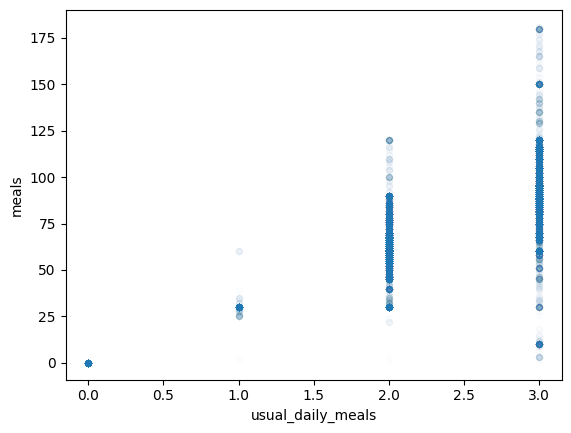

In [82]:
household_members.plot(kind='scatter', x='usual_daily_meals', y='meals', alpha=0.01)

In [83]:
household_meals = household_members.groupby("common_id").meals_at_home_last_30_days.sum()
household_meals

common_id
HCES2022310002282831212025 228111  301     30.0
HCES2022310002282831212025 228111  302    408.0
HCES2022310002282831212025 228111  303    450.0
HCES2022310002282831212025 228111  304    180.0
HCES2022310002282831212025 228111  305     30.0
                                          ...  
HCES2022699991212130123093 221201  312    671.0
HCES2022699991212130123093 221201  313    180.0
HCES2022699991212130123093 221201  314    360.0
HCES2022699991212130123093 221201  315    333.0
HCES2022699991212130123093 221201  316    480.0
Name: meals_at_home_last_30_days, Length: 259624, dtype: float64

In [84]:
consumption = consumption.merge(household_meals, on="common_id", validate="1:1", how="left")
consumption

,common_id,pds_rice,non_pds_rice_purchased,non_pds_rice_non_purchased,rice,proportion_non_pds_purchased,meals_at_home_last_30_days
0,HCES2022310002282831212025 228111 301,0.0,3.0,0.0,3.0,1.0,30.0
1,HCES2022310002282831212025 228111 302,6.0,18.0,0.0,24.0,1.0,408.0
2,HCES2022310002282831212025 228111 303,3.0,25.0,0.0,28.0,1.0,450.0
3,HCES2022310002282831212025 228111 304,3.0,12.0,0.0,15.0,1.0,180.0
4,HCES2022310002282831212025 228111 305,1.0,3.0,0.0,4.0,1.0,30.0
...,...,...,...,...,...,...,...
261741,HCES2022699991212130123093 221201 312,30.0,40.0,0.0,70.0,1.0,671.0
261742,HCES2022699991212130123093 221201 313,10.0,12.0,0.0,22.0,1.0,180.0
261743,HCES2022699991212130123093 221201 314,20.0,25.0,0.0,45.0,1.0,360.0
261744,HCES2022699991212130123093 221201 315,35.0,35.0,0.0,70.0,1.0,333.0


In [85]:
consumption.isnull().mean()

common_id                       0.000000
pds_rice                        0.000000
non_pds_rice_purchased          0.000000
non_pds_rice_non_purchased      0.000000
rice                            0.000000
proportion_non_pds_purchased    0.000000
meals_at_home_last_30_days      0.008107
dtype: float64

In [86]:
consumption = consumption.dropna(how="any").copy()
consumption

,common_id,pds_rice,non_pds_rice_purchased,non_pds_rice_non_purchased,rice,proportion_non_pds_purchased,meals_at_home_last_30_days
0,HCES2022310002282831212025 228111 301,0.0,3.0,0.0,3.0,1.0,30.0
1,HCES2022310002282831212025 228111 302,6.0,18.0,0.0,24.0,1.0,408.0
2,HCES2022310002282831212025 228111 303,3.0,25.0,0.0,28.0,1.0,450.0
3,HCES2022310002282831212025 228111 304,3.0,12.0,0.0,15.0,1.0,180.0
4,HCES2022310002282831212025 228111 305,1.0,3.0,0.0,4.0,1.0,30.0
...,...,...,...,...,...,...,...
261741,HCES2022699991212130123093 221201 312,30.0,40.0,0.0,70.0,1.0,671.0
261742,HCES2022699991212130123093 221201 313,10.0,12.0,0.0,22.0,1.0,180.0
261743,HCES2022699991212130123093 221201 314,20.0,25.0,0.0,45.0,1.0,360.0
261744,HCES2022699991212130123093 221201 315,35.0,35.0,0.0,70.0,1.0,333.0


In [87]:
consumption["rice_per_meal_kg"] = np.where(
    consumption.rice == 0,
    0.0,
    consumption.rice / consumption.meals_at_home_last_30_days
)

In [88]:
# In a small number of cases, rice consumption is reported despite very few or no meals at home
impossible_rice_consumption = (consumption.rice > 0) & (consumption.meals_at_home_last_30_days == 0)
consumption[impossible_rice_consumption]

,common_id,pds_rice,non_pds_rice_purchased,non_pds_rice_non_purchased,rice,proportion_non_pds_purchased,meals_at_home_last_30_days,rice_per_meal_kg
5845,HCES2022313712252510212018 124241 314,0.0,6.0,0.0,6.0,1.0,0.0,inf
15348,HCES2022319332272730332022 127111 309,2.0,3.0,0.0,5.0,1.0,0.0,inf
22433,HCES2022323692202021012028 220151 306,0.0,6.0,0.0,6.0,1.0,0.0,inf
31974,HCES2022329292222220422028 222121 308,0.0,0.0,8.0,8.0,0.0,0.0,inf
31977,HCES2022329292222220422028 222121 311,0.0,0.0,12.0,12.0,0.0,0.0,inf
31980,HCES2022329292222220422028 222121 314,0.0,0.0,12.0,12.0,0.0,0.0,inf
31983,HCES2022329292222220422028 222121 317,0.0,0.0,12.0,12.0,0.0,0.0,inf
48967,HCES2022339822171710622012 217101 313,0.0,5.0,0.0,5.0,1.0,0.0,inf
49455,HCES2022341092363612342053 236102 314,0.0,10.0,0.0,10.0,1.0,0.0,inf
50369,HCES2022341602363612342015 236101 314,0.0,8.0,0.0,8.0,1.0,0.0,inf


In [89]:
# This must be wrong somehow, so we clip it
consumption["rice_per_meal_kg"] = consumption["rice_per_meal_kg"].clip(upper=np.percentile(consumption.rice_per_meal_kg, 95))

<Axes: >

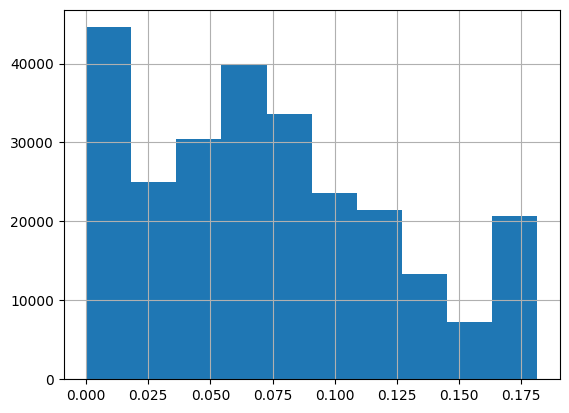

In [90]:
consumption[consumption.rice_per_meal_kg.notnull()].sort_values('rice_per_meal_kg')
consumption.rice_per_meal_kg.hist()

<Axes: >

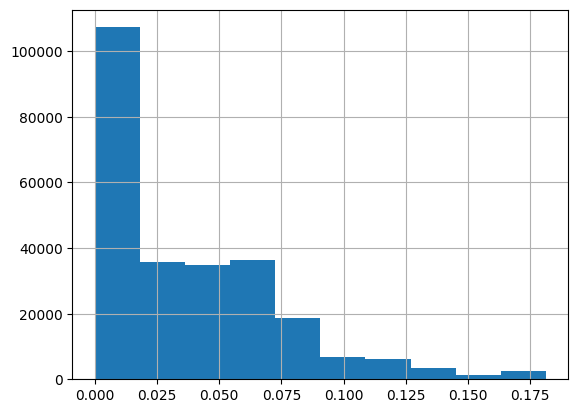

In [91]:
consumption["pds_rice_per_meal_kg"] = consumption.rice_per_meal_kg * (consumption.pds_rice / consumption.rice)
consumption.pds_rice_per_meal_kg.hist()

In [92]:
household_members = household_members.merge(
    consumption.reset_index()[["common_id", "rice_per_meal_kg", "pds_rice_per_meal_kg", "proportion_non_pds_purchased"]],
    on="common_id",
    how="left",
    validate="m:1",
)
household_members

,common_id,gender,age_years,multiplier,usual_daily_meals,meals_from_school_balwadi_last_30_days,meals_from_employer_last_30_days,meals_others_last_30_days,meals_paid_last_30_days,meals_at_home_last_30_days,wealth_quintile,meals,rice_per_meal_kg,pds_rice_per_meal_kg,proportion_non_pds_purchased
0,HCES2022655561010131113011 101202 201,Male,48,35560.0,2.0,0.0,0.0,0.0,0.0,58.0,highest,58.0,0.139860,0.000000,1.0
1,HCES2022655561010131113011 101202 201,Female,46,35560.0,2.0,0.0,0.0,0.0,0.0,60.0,highest,60.0,0.139860,0.000000,1.0
2,HCES2022655561010131113011 101202 201,Male,24,35560.0,2.0,0.0,0.0,0.0,0.0,58.0,highest,58.0,0.139860,0.000000,1.0
3,HCES2022655561010131113011 101202 201,Male,18,35560.0,2.0,0.0,0.0,0.0,0.0,56.0,highest,56.0,0.139860,0.000000,1.0
4,HCES2022655561010131113011 101202 201,Female,21,35560.0,2.0,0.0,0.0,0.0,0.0,54.0,highest,54.0,0.139860,0.000000,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1118622,HCES20223492023737102120110201201 313,Male,40,938.0,2.0,0.0,0.0,0.0,5.0,55.0,fourth,60.0,0.101695,0.067797,1.0
1118623,HCES20223492023737102120110201201 313,Female,38,938.0,2.0,0.0,0.0,0.0,0.0,60.0,fourth,60.0,0.101695,0.067797,1.0
1118624,HCES20223492023737102120110201201 313,Male,12,938.0,2.0,0.0,0.0,0.0,0.0,60.0,fourth,60.0,0.101695,0.067797,1.0
1118625,HCES20223492023737102120110201201 313,Female,7,938.0,2.0,0.0,0.0,0.0,0.0,60.0,fourth,60.0,0.101695,0.067797,1.0


In [93]:
household_members.isnull().mean()

common_id                                 0.000000
gender                                    0.000000
age_years                                 0.000000
multiplier                                0.000000
usual_daily_meals                         0.000000
meals_from_school_balwadi_last_30_days    0.000000
meals_from_employer_last_30_days          0.000000
meals_others_last_30_days                 0.000000
meals_paid_last_30_days                   0.000000
meals_at_home_last_30_days                0.000000
wealth_quintile                           0.000000
meals                                     0.000000
rice_per_meal_kg                          0.000000
pds_rice_per_meal_kg                      0.017985
proportion_non_pds_purchased              0.000000
dtype: float64

In [94]:
household_members["government_meals_away_from_home"] = household_members.meals_from_school_balwadi_last_30_days
household_members["non_government_meals_away_from_home"] = household_members.meals - household_members.meals_at_home_last_30_days - household_members.government_meals_away_from_home
household_members["rice"] = (
    household_members.meals * household_members.rice_per_meal_kg
)
household_members["government_rice"] = (
    household_members.meals_at_home_last_30_days * household_members.pds_rice_per_meal_kg +
    (household_members.government_meals_away_from_home * household_members.rice_per_meal_kg) +
    (household_members.non_government_meals_away_from_home * household_members.pds_rice_per_meal_kg) # Assume same as at-home meals
)
household_members["proportion_government"] = household_members.government_rice / household_members.rice
household_members["proportion_fortifiable"] = (
    # It's assumed that all non-government rice you consume is fortifiable if it was purchased; we use your household's rate of
    # purchasing vs growing for non-PDS rice for this.
    # All government rice is fortifiable.
    (household_members.government_rice + (household_members.proportion_non_pds_purchased * (household_members.rice - household_members.government_rice))) /
    household_members.rice
)

In [95]:
household_members.isnull().mean()

common_id                                 0.000000
gender                                    0.000000
age_years                                 0.000000
multiplier                                0.000000
usual_daily_meals                         0.000000
meals_from_school_balwadi_last_30_days    0.000000
meals_from_employer_last_30_days          0.000000
meals_others_last_30_days                 0.000000
meals_paid_last_30_days                   0.000000
meals_at_home_last_30_days                0.000000
wealth_quintile                           0.000000
meals                                     0.000000
rice_per_meal_kg                          0.000000
pds_rice_per_meal_kg                      0.017985
proportion_non_pds_purchased              0.000000
government_meals_away_from_home           0.000000
non_government_meals_away_from_home       0.000000
rice                                      0.000000
government_rice                           0.017985
proportion_government          

In [96]:
# Convert kg/30 days to g/day
household_members["rice_g_per_day"] = household_members.rice / 30 * 1_000

In [97]:
household_members["sex"] = household_members.gender.replace({"Transgender": np.nan}) # We don't know the sex of transgender people in the survey :(
age_bin_edges = [0, 5, 15, 30, 50, 100]
age_group = pd.IntervalIndex(
    pd.cut(household_members.age_years, age_bin_edges, right=False, include_lowest=True)
)
household_members["age_start"] = age_group.left
household_members["age_end"] = age_group.right

In [98]:
# https://stackoverflow.com/a/2415343/ with some tweaks
def weighted_avg_and_std(values, weights):
    """
    Return the weighted average and standard deviation.

    They weights are in effect first normalized so that they
    sum to 1 (and so they must not all be 0).

    values, weights -- NumPy ndarrays with the same shape.
    """
    is_nan = np.isnan(values)
    values = values[~is_nan]
    weights = weights[~is_nan]
    average = np.average(values, weights=weights)
    # Fast and numerically precise:
    variance = np.average((values - average) ** 2, weights=weights)
    return pd.Series(
        {
            "mean": average,
            "sd": np.sqrt(variance),
            # https://ngreifer.github.io/WeightIt/reference/ESS.html
            "effective_sample_size": (weights.sum() ** 2) / (weights**2).sum(),
        }
    )

In [99]:
results_dir = '../results/'

In [100]:
import pathlib

def save_data(series, name):
    path = f'{results_dir}/{name}/india.csv'
    pathlib.Path(path).parent.mkdir(exist_ok=True, parents=True)
    (
        series.rename("value").reset_index()
            .assign(vehicle_name='rice')
            .to_csv(path, index=False)
    )

def save_for_each_fortificant(series, name):
    save_data(series, f"iron/{name}")
    save_data(series, f"folate/{name}")

In [101]:
# NOTE: We do not have pregnancy status in this survey, so we assume it has no effect on consumption!
any_consumption = (
    household_members.groupby(["sex", "age_start", "age_end", "wealth_quintile"], observed=True)
    .apply(lambda df: weighted_avg_and_std(df.rice_g_per_day > 0, weights=df.multiplier))
    .sort_index()
)
any_consumption

/tmp/ipykernel_2495828/4066145174.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: weighted_avg_and_std(df.rice_g_per_day > 0, weights=df.multiplier))


mean        sd  \
sex    age_start age_end wealth_quintile                       
Female 0.0       5.0     lowest           0.919076  0.272719   
                         second           0.887756  0.315666   
                         middle           0.875160  0.330538   
                         fourth           0.874946  0.330780   
                         highest          0.879201  0.325894   
       5.0       15.0    lowest           0.987435  0.111387   
                         second           0.971206  0.167228   
                         middle           0.976108  0.152712   
                         fourth           0.985006  0.121528   
                         highest          0.988478  0.106719   
       15.0      30.0    lowest           0.989477  0.102039   
                         second           0.962284  0.190509   
                         middle           0.949051  0.219894   
                         fourth           0.983526  0.127291   
                         highest          0.987731  0.110086   
       30.0      50.0    lowest           0.991169  0.093556   
                         second           0.980521  0.138203   
                         middle           0.979261  0.142508   
                         fourth           0.986777  0.114228   
                         highest          0.988428  0.106947   
       50.0      100.0   lowest           0.987287  0.112034   
                         second           0.974140  0.158718   
                         middle           0.976558  0.151303   
                         fourth           0.985695  0.118744   
                         highest          0.986890  0.113746   
Male   0.0       5.0     lowest           0.918771  0.273187   
                         second           0.884489  0.319638   
                         middle           0.875467  0.330189   
                         fourth           0.876535  0.328970   
                         highest          0.877939  0.327356   
       5.0       15.0    lowest           0.988832  0.105087   
                         second           0.972957  0.162210   
                         middle           0.973361  0.161026   
                         fourth           0.984239  0.124550   
                         highest          0.986266  0.116384   
       15.0      30.0    lowest           0.990754  0.095712   
                         second           0.958654  0.199090   
                         middle           0.952879  0.211899   
                         fourth           0.979735  0.140904   
                         highest          0.987952  0.109100   
       30.0      50.0    lowest           0.991017  0.094354   
                         second           0.978177  0.146107   
                         middle           0.975512  0.154558   
                         fourth           0.984333  0.124183   
                         highest          0.987183  0.112484   
       50.0      100.0   lowest           0.988332  0.107388   
                         second           0.975913  0.153319   
                         middle           0.976137  0.152624   
                         fourth           0.985464  0.119687   
                         highest          0.987380  0.111627   

                                          effective_sample_size  
sex    age_start age_end wealth_quintile                         
Female 0.0       5.0     lowest                     1743.263215  
                         second                     5982.871624  
                         middle                     5084.488296  
                         fourth                     4406.862764  
                         highest                    3828.948193  
       5.0       15.0    lowest                     7488.653662  
                         second                     8286.919576  
                         middle                    13114.610332  
                         fourth                    11533.

In [102]:
save_data(any_consumption["mean"], "vehicle_consumption/any")

In [103]:
consumption_amount = (
    household_members.groupby(["sex", "age_start", "age_end", "wealth_quintile"], observed=True)
    .apply(lambda df: weighted_avg_and_std(df.rice_g_per_day, weights=df.multiplier))
    .sort_index()
)
consumption_amount

/tmp/ipykernel_2495828/664766383.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: weighted_avg_and_std(df.rice_g_per_day, weights=df.multiplier))


mean          sd  \
sex    age_start age_end wealth_quintile                           
Female 0.0       5.0     lowest           185.559631  121.168311   
                         second           147.531394  116.095056   
                         middle           129.130302  110.752293   
                         fourth           127.809856  108.603282   
                         highest          102.815078   95.141765   
       5.0       15.0    lowest           215.163368  120.989510   
                         second           169.661789  117.448466   
                         middle           157.826906  112.525742   
                         fourth           156.308481  111.517447   
                         highest          121.855134   98.613841   
       15.0      30.0    lowest           206.658250  119.447794   
                         second           168.712347  118.592026   
                         middle           153.034877  115.173905   
                         fourth           154.403933  112.840694   
                         highest          126.165615  104.458984   
       30.0      50.0    lowest           216.769670  123.974671   
                         second           180.227007  122.464593   
                         middle           171.532393  119.434941   
                         fourth           170.113479  118.592201   
                         highest          128.315368  105.405824   
       50.0      100.0   lowest           219.499591  128.019116   
                         second           185.910953  126.934519   
                         middle           178.795062  124.494621   
                         fourth           168.980357  117.849517   
                         highest          130.470024  105.715161   
Male   0.0       5.0     lowest           185.278819  123.182430   
                         second           146.516138  116.989434   
                         middle           129.446363  108.313003   
                         fourth           124.818321  105.573154   
                         highest          100.678651   93.941297   
       5.0       15.0    lowest           216.893196  121.443966   
                         second           172.804443  117.958078   
                         middle           159.388125  114.651441   
                         fourth           154.550355  111.852587   
                         highest          121.923356  100.086388   
       15.0      30.0    lowest           213.744900  120.883650   
                         second           172.092404  121.778682   
                         middle           155.929784  118.510235   
                         fourth           158.940278  117.003970   
                         highest          125.210198  106.312501   
       30.0      50.0    lowest           213.007652  124.468151   
                         second           175.759177  122.006749   
                         middle           164.240333  117.752305   
                         fourth           164.063506  118.720777   
                         highest          125.755082  105.263856   
       50.0      100.0   lowest           222.014920  127.115173   
                         second           185.229961  123.909343   
                         middle           176.119701  121.741408   
                         fourth           170.731948  118.354400   
                         highest          133.144195  107.696365   

                                          effective_sample_size  
sex    age_start age_end wealth_quintile                         
Female 0.0       5.0     lowest                     1743.263215  
                         second                     5982.871624  
                         middle                     5084.488296  
                         fourth                     4406.862764  
                         highest                    3828.948193  
       5.0       15.0    lowest                  

In [104]:
save_data(consumption_amount["mean"], "vehicle_consumption/amount/mean")
save_data(consumption_amount["sd"], "vehicle_consumption/amount/sd")

In [105]:
# NOTE: Government rice fortification scale-up is still in progress.
# According to this dashboard (https://impds.nic.in/sale/stateUnautmated?month=1&year=2024) it is
# around 70% in 2024. We say that it can't get above 80% due to compliance issues.
# We apply maximum individual heterogeneity, meaning that the people who are missed
# due to compliance are *completely* missed.
GOVERNMENT_BASELINE_COVERAGE = 0.8

In [106]:
any_fortification = (
    household_members.groupby(["sex", "age_start", "age_end", "wealth_quintile"], observed=True)
    .apply(lambda df: GOVERNMENT_BASELINE_COVERAGE * weighted_avg_and_std(df.proportion_government > 0, weights=df.multiplier))
    .sort_index()
)
any_fortification

/tmp/ipykernel_2495828/1017426664.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: GOVERNMENT_BASELINE_COVERAGE * weighted_avg_and_std(df.proportion_government > 0, weights=df.multiplier))


mean        sd  \
sex    age_start age_end wealth_quintile                       
Female 0.0       5.0     lowest           0.560845  0.366236   
                         second           0.535335  0.376410   
                         middle           0.492510  0.389155   
                         fourth           0.454610  0.396255   
                         highest          0.293520  0.385567   
       5.0       15.0    lowest           0.713577  0.248333   
                         second           0.671205  0.294020   
                         middle           0.624088  0.331337   
                         fourth           0.568540  0.362759   
                         highest          0.360006  0.397996   
       15.0      30.0    lowest           0.642256  0.318295   
                         second           0.612181  0.339086   
                         middle           0.545258  0.372693   
                         fourth           0.514132  0.383372   
                         highest          0.333364  0.394410   
       30.0      50.0    lowest           0.690475  0.274998   
                         second           0.645809  0.315559   
                         middle           0.588235  0.352942   
                         fourth           0.537686  0.375556   
                         highest          0.312764  0.390372   
       50.0      100.0   lowest           0.696931  0.268015   
                         second           0.650967  0.311473   
                         middle           0.598906  0.347039   
                         fourth           0.540292  0.374591   
                         highest          0.311944  0.390187   
Male   0.0       5.0     lowest           0.565099  0.364338   
                         second           0.537732  0.375540   
                         middle           0.488015  0.390197   
                         fourth           0.454173  0.396315   
                         highest          0.278514  0.381105   
       5.0       15.0    lowest           0.717446  0.243368   
                         second           0.667476  0.297416   
                         middle           0.611079  0.339773   
                         fourth           0.560454  0.366407   
                         highest          0.345303  0.396243   
       15.0      30.0    lowest           0.678976  0.286657   
                         second           0.610257  0.340282   
                         middle           0.530221  0.378210   
                         fourth           0.515154  0.383066   
                         highest          0.325438  0.392989   
       30.0      50.0    lowest           0.667364  0.297517   
                         second           0.622329  0.332520   
                         middle           0.554589  0.368921   
                         fourth           0.521644  0.381055   
                         highest          0.306734  0.388975   
       50.0      100.0   lowest           0.696972  0.267970   
                         second           0.649029  0.313025   
                         middle           0.593358  0.350161   
                         fourth           0.536023  0.376162   
                         highest          0.309946  0.389731   

                                          effective_sample_size  
sex    age_start age_end wealth_quintile                         
Female 0.0       5.0     lowest                     1394.610572  
                         second                     4786.297299  
                         middle                     4067.590636  
                         fourth                     3525.490211  
                         highest                    3063.158555  
       5.0       15.0    lowest                     5990.922929  
                         second                     6629.535661  
                         middle                    10491.688266  
                         fourth                     9226.

In [107]:
save_for_each_fortificant(any_fortification["mean"], "baseline_fortification/any_coverage")

In [108]:
full_fortification = (
    household_members.groupby(["sex", "age_start", "age_end", "wealth_quintile"], observed=True)
    .apply(lambda df: GOVERNMENT_BASELINE_COVERAGE * weighted_avg_and_std(df.proportion_government == 1, weights=df.multiplier))
    .sort_index()
)
full_fortification

/tmp/ipykernel_2495828/1006443878.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: GOVERNMENT_BASELINE_COVERAGE * weighted_avg_and_std(df.proportion_government == 1, weights=df.multiplier))


mean        sd  \
sex    age_start age_end wealth_quintile                       
Female 0.0       5.0     lowest           0.156303  0.317193   
                         second           0.173319  0.329569   
                         middle           0.172177  0.328781   
                         fourth           0.123566  0.289110   
                         highest          0.062838  0.215225   
       5.0       15.0    lowest           0.177188  0.332197   
                         second           0.198127  0.345322   
                         middle           0.182862  0.335933   
                         fourth           0.146883  0.309729   
                         highest          0.077928  0.237213   
       15.0      30.0    lowest           0.174926  0.330669   
                         second           0.205154  0.349335   
                         middle           0.183202  0.336153   
                         fourth           0.155341  0.316452   
                         highest          0.084083  0.245350   
       30.0      50.0    lowest           0.190169  0.340545   
                         second           0.217525  0.355954   
                         middle           0.194134  0.342956   
                         fourth           0.149396  0.311766   
                         highest          0.073078  0.230482   
       50.0      100.0   lowest           0.229927  0.362043   
                         second           0.228605  0.361419   
                         middle           0.201205  0.347103   
                         fourth           0.154313  0.315655   
                         highest          0.067050  0.221685   
Male   0.0       5.0     lowest           0.161586  0.321183   
                         second           0.182911  0.335965   
                         middle           0.167148  0.325238   
                         fourth           0.125321  0.290777   
                         highest          0.068091  0.223241   
       5.0       15.0    lowest           0.180612  0.334468   
                         second           0.205132  0.349323   
                         middle           0.184527  0.337003   
                         fourth           0.149893  0.312164   
                         highest          0.078067  0.237401   
       15.0      30.0    lowest           0.188803  0.339700   
                         second           0.207534  0.350652   
                         middle           0.188434  0.339470   
                         fourth           0.160453  0.320339   
                         highest          0.084996  0.246520   
       30.0      50.0    lowest           0.179371  0.333651   
                         second           0.207879  0.350841   
                         middle           0.181731  0.335199   
                         fourth           0.143196  0.306678   
                         highest          0.070688  0.227054   
       50.0      100.0   lowest           0.214776  0.354531   
                         second           0.215544  0.354931   
                         middle           0.188813  0.339706   
                         fourth           0.148145  0.310755   
                         highest          0.067361  0.222152   

                                          effective_sample_size  
sex    age_start age_end wealth_quintile                         
Female 0.0       5.0     lowest                     1394.610572  
                         second                     4786.297299  
                         middle                     4067.590636  
                         fourth                     3525.490211  
                         highest                    3063.158555  
       5.0       15.0    lowest                     5990.922929  
                         second                     6629.535661  
                         middle                    10491.688266  
                         fourth                     9226.

In [109]:
save_for_each_fortificant(full_fortification["mean"], "baseline_fortification/full_coverage")

In [110]:
# Remember, we've assumed maximum heterogeneity here, so the people who are partially covered
# have *all* of their government rice fortified.
partial_fortification_amount = (
    household_members[(household_members.proportion_government > 0) & (household_members.proportion_government < 1)].groupby(["sex", "age_start", "age_end", "wealth_quintile"], observed=True)
    .apply(lambda df: weighted_avg_and_std(df.proportion_government, weights=df.multiplier))
    .sort_index()
)
partial_fortification_amount

/tmp/ipykernel_2495828/952676039.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: weighted_avg_and_std(df.proportion_government, weights=df.multiplier))


mean        sd  \
sex    age_start age_end wealth_quintile                       
Female 0.0       5.0     lowest           0.524382  0.203527   
                         second           0.552721  0.193385   
                         middle           0.551125  0.205578   
                         fourth           0.530210  0.214187   
                         highest          0.471885  0.212866   
       5.0       15.0    lowest           0.566689  0.206855   
                         second           0.565275  0.216972   
                         middle           0.560457  0.227338   
                         fourth           0.535734  0.224606   
                         highest          0.477592  0.223359   
       15.0      30.0    lowest           0.535427  0.189955   
                         second           0.563819  0.187441   
                         middle           0.558023  0.196571   
                         fourth           0.538286  0.204136   
                         highest          0.495222  0.210662   
       30.0      50.0    lowest           0.538643  0.184784   
                         second           0.558521  0.189831   
                         middle           0.553285  0.197847   
                         fourth           0.526279  0.202554   
                         highest          0.482992  0.208895   
       50.0      100.0   lowest           0.537533  0.185388   
                         second           0.557930  0.187527   
                         middle           0.548081  0.195912   
                         fourth           0.516063  0.202565   
                         highest          0.470680  0.206000   
Male   0.0       5.0     lowest           0.532374  0.200598   
                         second           0.558836  0.195566   
                         middle           0.556791  0.205189   
                         fourth           0.529620  0.217144   
                         highest          0.486610  0.204447   
       5.0       15.0    lowest           0.567170  0.206978   
                         second           0.572410  0.216182   
                         middle           0.556877  0.223415   
                         fourth           0.543621  0.223986   
                         highest          0.483479  0.224121   
       15.0      30.0    lowest           0.536914  0.187172   
                         second           0.563922  0.187654   
                         middle           0.565248  0.197746   
                         fourth           0.538013  0.202756   
                         highest          0.501369  0.209181   
       30.0      50.0    lowest           0.540037  0.187875   
                         second           0.559057  0.191238   
                         middle           0.556129  0.199491   
                         fourth           0.530613  0.205464   
                         highest          0.488715  0.212137   
       50.0      100.0   lowest           0.538069  0.184063   
                         second           0.558119  0.188782   
                         middle           0.549812  0.198204   
                         fourth           0.520823  0.202486   
                         highest          0.471630  0.203321   

                                          effective_sample_size  
sex    age_start age_end wealth_quintile                         
Female 0.0       5.0     lowest                      768.000671  
                         second                     2664.573354  
                         middle                     2037.290517  
                         fourth                     1796.303455  
                         highest                    1065.584188  
       5.0       15.0    lowest                     5185.031778  
                         second                     3578.621728  
                         middle                     6986.144560  
                         fourth                     6002.

In [111]:
save_for_each_fortificant(partial_fortification_amount["mean"], "baseline_fortification/partial_coverage_amount/mean")
save_for_each_fortificant(partial_fortification_amount["sd"], "baseline_fortification/partial_coverage_amount/sd")

In [112]:
proportion_government = (
    household_members.groupby(["sex", "age_start", "age_end", "wealth_quintile"], observed=True)
    .apply(lambda df: weighted_avg_and_std(df.proportion_government, weights=df.multiplier))
    .sort_index()
)
proportion_government

/tmp/ipykernel_2495828/2451478109.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: weighted_avg_and_std(df.proportion_government, weights=df.multiplier))


mean        sd  \
sex    age_start age_end wealth_quintile                       
Female 0.0       5.0     lowest           0.503039  0.369334   
                         second           0.527613  0.378342   
                         middle           0.500180  0.396368   
                         fourth           0.430452  0.387840   
                         highest          0.245303  0.344558   
       5.0       15.0    lowest           0.615470  0.319326   
                         second           0.606134  0.347778   
                         middle           0.557332  0.373623   
                         fourth           0.477339  0.381071   
                         highest          0.270965  0.356550   
       15.0      30.0    lowest           0.538390  0.351529   
                         second           0.566315  0.367397   
                         middle           0.509466  0.389484   
                         fourth           0.444688  0.391685   
                         highest          0.263671  0.360151   
       30.0      50.0    lowest           0.581191  0.329930   
                         second           0.584176  0.358995   
                         middle           0.528426  0.381590   
                         fourth           0.450414  0.382243   
                         highest          0.239937  0.346912   
       50.0      100.0   lowest           0.610802  0.334549   
                         second           0.598064  0.356216   
                         middle           0.538773  0.378123   
                         fourth           0.450057  0.382242   
                         highest          0.231910  0.338225   
Male   0.0       5.0     lowest           0.513627  0.368665   
                         second           0.541064  0.380749   
                         middle           0.495866  0.396479   
                         fourth           0.429582  0.389094   
                         highest          0.244333  0.350655   
       5.0       15.0    lowest           0.619527  0.318041   
                         second           0.609293  0.350843   
                         middle           0.548492  0.377747   
                         fourth           0.478245  0.385022   
                         highest          0.264599  0.357425   
       15.0      30.0    lowest           0.572493  0.337162   
                         second           0.569044  0.368388   
                         middle           0.503691  0.398490   
                         fourth           0.450695  0.393465   
                         highest          0.261978  0.362483   
       30.0      50.0    lowest           0.561090  0.340926   
                         second           0.564597  0.368784   
                         middle           0.501727  0.390572   
                         fourth           0.439921  0.385142   
                         highest          0.237386  0.347167   
       50.0      100.0   lowest           0.601688  0.331095   
                         second           0.588060  0.355108   
                         middle           0.529181  0.377442   
                         fourth           0.446281  0.381345   
                         highest          0.231184  0.338117   

                                          effective_sample_size  
sex    age_start age_end wealth_quintile                         
Female 0.0       5.0     lowest                     1503.844854  
                         second                     5291.275282  
                         middle                     4485.976336  
                         fourth                     3879.176497  
                         highest                    3450.504018  
       5.0       15.0    lowest                     7341.325826  
                         second                     7936.785902  
                         middle                    12751.097252  
                         fourth                    11339.

In [113]:
# Save locally for further scaling in the extraction notebook
proportion_government["mean"].rename("value").to_csv('india_proportion_government.csv')

In [114]:
fortifiability_disparities = (
    household_members.groupby(["sex", "age_start", "age_end", "wealth_quintile"], observed=True)
    .apply(lambda df: weighted_avg_and_std(df.proportion_fortifiable, weights=df.multiplier))
    .sort_index()
)
fortifiability_disparities

/tmp/ipykernel_2495828/407707326.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda df: weighted_avg_and_std(df.proportion_fortifiable, weights=df.multiplier))


mean        sd  \
sex    age_start age_end wealth_quintile                       
Female 0.0       5.0     lowest           0.904069  0.230732   
                         second           0.912038  0.225906   
                         middle           0.936790  0.202122   
                         fourth           0.943932  0.202517   
                         highest          0.968502  0.160094   
       5.0       15.0    lowest           0.915658  0.198750   
                         second           0.923362  0.202092   
                         middle           0.941802  0.187908   
                         fourth           0.950344  0.184573   
                         highest          0.968046  0.164011   
       15.0      30.0    lowest           0.893274  0.234412   
                         second           0.907431  0.226839   
                         middle           0.931873  0.207168   
                         fourth           0.943990  0.199686   
                         highest          0.966662  0.167110   
       30.0      50.0    lowest           0.893193  0.230826   
                         second           0.911487  0.221166   
                         middle           0.936877  0.201680   
                         fourth           0.945105  0.197919   
                         highest          0.966681  0.169044   
       50.0      100.0   lowest           0.888275  0.237827   
                         second           0.909722  0.223488   
                         middle           0.930755  0.211660   
                         fourth           0.938537  0.210453   
                         highest          0.963072  0.177137   
Male   0.0       5.0     lowest           0.904259  0.232048   
                         second           0.916368  0.220639   
                         middle           0.925687  0.220128   
                         fourth           0.947889  0.194017   
                         highest          0.964339  0.172133   
       5.0       15.0    lowest           0.913728  0.200113   
                         second           0.920906  0.206438   
                         middle           0.940270  0.191763   
                         fourth           0.949625  0.186928   
                         highest          0.965496  0.170654   
       15.0      30.0    lowest           0.896807  0.228625   
                         second           0.907547  0.224364   
                         middle           0.935239  0.203672   
                         fourth           0.943431  0.201371   
                         highest          0.963456  0.175388   
       30.0      50.0    lowest           0.893053  0.235059   
                         second           0.913740  0.221392   
                         middle           0.936099  0.204563   
                         fourth           0.947246  0.194522   
                         highest          0.966760  0.168399   
       50.0      100.0   lowest           0.881223  0.243140   
                         second           0.898771  0.235635   
                         middle           0.924525  0.219680   
                         fourth           0.934001  0.217676   
                         highest          0.962530  0.178506   

                                          effective_sample_size  
sex    age_start age_end wealth_quintile                         
Female 0.0       5.0     lowest                     1503.844854  
                         second                     5291.275282  
                         middle                     4485.976336  
                         fourth                     3879.176497  
                         highest                    3450.504018  
       5.0       15.0    lowest                     7341.325826  
                         second                     7936.785902  
                         middle                    12751.097252  
                         fourth                    11339.

In [115]:
# Save locally for further scaling in the extraction notebook
fortifiability_disparities["mean"].rename("value").to_csv('india_fortifiability_disparities.csv')